# 🔧 YOLO Optimization Pipeline (corrected)
## Pruning · Quantization · Knowledge Distillation · Comparative Analysis

**Models:** `yolov5nu` · `yolov5su` · `yolov8n` · `yolov8s` · `yolo11n`
**Loads pre-trained `best.pt` weights — NO retraining from scratch**
**Task:** Streetlight Detection (`onstreetlight` · `offstreetlight`)

---
### What changed vs the previous version
The old pipeline ran without errors but produced misleading numbers because of several silent bugs.
This version fixes the methodology so the reported metrics actually mean what they claim:

1. **Dynamic INT8 in PyTorch is no longer used on Conv2d** — it's a no-op there. We use **ONNX Runtime
   dynamic INT8** (which does support Conv) and **FP16** as honest, deployable alternatives.
2. **Pruning now also reports `FileSizeMB_gz`** — gzip size of the saved weights, which is the
   realistic on-device size for unstructured pruning. Dense FP32 file size barely changes.
3. **The detection head is excluded from pruning** — pruning the final 1×1 convs of `Detect` was
   collapsing mAP unnecessarily.
4. **Iterative pruning now keeps prune masks attached during fine-tuning** — the previous version
   called `prune.remove()` between steps, which let the zeroed weights regrow during fine-tuning.
5. **The KD trainer actually injects the KD loss** — the previous `train_step` override was dead
   code (never called by `BaseTrainer._do_train`). We now wrap `model.loss` directly.
6. **RPi FPS is measured, not formula-estimated** — we benchmark the exported ONNX model on CPU with
   threads pinned to mimic an RPi 4. The old `55 * params^-0.75` formula produced fake speed numbers.
7. **`benchmark_fps_gpu` no longer mutates the model in-place** — the old version called
   `model.model.to(device)` which broke subsequent `.val()` calls.

---
### Additional fixes in this revision
8. **Iterative pruning data path resolved** — uses `check_det_dataset()` so the train images path is absolute regardless of the `path:` prefix in `data.yaml`.
9. **KD trainer instantiation fixed** — passes `overrides=dict(...)` instead of a pre-cooked `cfg`, avoiding the `'NoneType' object has no attribute 'pop'` crash on recent Ultralytics.
10. **All 4 trained variants enabled** — `yolov5nu`, `yolov5su`, `yolov8n`, `yolov8s` (plus a second KD pair `v8s→v8n`).
11. **Auto-download to PC** — new Cell A8 zips outputs and triggers a browser download + Drive backup, so a Colab runtime reset doesn't wipe your work.


## 📦 Cell 1 — Install Dependencies

In [6]:
# Run once, then comment out
!pip install ultralytics -q
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install onnx onnxruntime onnxruntime-tools -q
!pip install pandas matplotlib seaborn scipy scikit-learn -q
print("✅ Dependencies installed")

✅ Dependencies installed


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📚 Cell 2 — Imports

In [8]:
import os, copy, time, json, warnings, gc, gzip, shutil, tempfile
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.utils.prune as prune
from pathlib import Path
from ultralytics import YOLO

# Optional ONNX Runtime imports - some quantization features require them
try:
    import onnx
    import onnxruntime as ort
    from onnxruntime.quantization import quantize_dynamic, QuantType
    HAS_ORT = True
except Exception as e:
    print(f"[WARN] ONNX Runtime not fully available: {e}")
    HAS_ORT = False

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
sns.set_palette('husl')

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"ORT      : {HAS_ORT}")

PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : cuda
ORT      : True


## ⚙️ Cell 3 — Global Configuration

In [ ]:
CFG = dict(
    data_yaml     = "data.yaml",
    save_dir      = "saved_models",         # where your best.pt files live
    opt_dir       = "optimized_models",     # where we save pruned/quant models
    onnx_dir      = "onnx_exports",         # where we save ONNX exports for benchmarking
    device        = "cuda" if torch.cuda.is_available() else "cpu",
    imgsz         = 640,
    batch_val     = 16,
    num_classes   = 2,
    class_names   = ["onstreetlight", "offstreetlight"],

    # CPU benchmark threads to mimic Raspberry Pi 4 (4 cores, but we leave 1 for OS).
    # Lower this to 2 if you want a more conservative estimate.
    rpi_threads   = 4,
    bench_warmup  = 5,
    bench_runs    = 30,

    # Pruning safety: never prune the last N Conv2d layers of the network. The detection
    # head's 1x1 convs are tiny and crucial — pruning them collapses mAP for no size win.
    prune_skip_last_n_convs = 6,
)

# ── 4 YOLO variants you trained (best.pt files in saved_models/) ────────────
YOLO_VARIANTS = {
    "yolov5nu" : "YOLOv5n",
    "yolov5su" : "YOLOv5s",
    "yolov8n"  : "YOLOv8n",
    "yolov8s"  : "YOLOv8s",
}

# ── Teacher → Student pairs for KD ──────────────────────────────────────────
KD_PAIRS = [
    {"teacher": "yolov5su", "student": "yolov5nu", "label": "v5s→v5n"},
    {"teacher": "yolov8s",  "student": "yolov8n",  "label": "v8s→v8n"},
]

os.makedirs(CFG["opt_dir"],  exist_ok=True)
os.makedirs(CFG["onnx_dir"], exist_ok=True)

RESULTS   = []   # global results collector
PRUNE_LOG = []   # per-model, per-sparsity pruning results

def saved_path(tag):
    """Path to the original saved best.pt for a variant tag."""
    return f"{CFG['save_dir']}/{tag}.pt"

def opt_path(name):
    """Path inside optimized_models/."""
    return f"{CFG['opt_dir']}/{name}.pt"

def onnx_path(name):
    """Path inside onnx_exports/."""
    return f"{CFG['onnx_dir']}/{name}.onnx"

print("Config OK. Device:", CFG["device"])
print("YOLO variants:", list(YOLO_VARIANTS.keys()))
print("KD pairs    :", [p["label"] for p in KD_PAIRS])


## 🛠️ Cell 4 — Utility Functions

In [10]:
# ────────────────────────────────────────────────────────────────────────────
#  Model loading
# ────────────────────────────────────────────────────────────────────────────
def load_yolo(tag):
    """Load YOLO from saved best.pt."""
    path = saved_path(tag)
    assert os.path.exists(path), f"Missing: {path}"
    return YOLO(path)


# ────────────────────────────────────────────────────────────────────────────
#  Evaluation helpers
# ────────────────────────────────────────────────────────────────────────────
def eval_yolo(model, tag, category, extra=None):
    """
    Validate YOLO model and return a results dict.
    Note: model.val() does its own device handling — we don't need to mutate the model.
    """
    m   = model.val(data=CFG["data_yaml"], imgsz=CFG["imgsz"],
                    batch=CFG["batch_val"], verbose=False)
    rd  = m.results_dict
    p   = rd.get("metrics/precision(B)", 0.0)
    r   = rd.get("metrics/recall(B)",    0.0)
    m50 = rd.get("metrics/mAP50(B)",     0.0)
    m95 = rd.get("metrics/mAP50-95(B)",  0.0)
    f1  = 2 * p * r / (p + r + 1e-16)
    row = dict(
        Tag=tag, Category=category,
        Precision=round(p,  4), Recall=round(r,   4),
        mAP50    =round(m50, 4), mAP50_95=round(m95, 4),
        F1       =round(f1,  4),
    )
    if extra:
        row.update(extra)
    return row


# ────────────────────────────────────────────────────────────────────────────
#  Model size
# ────────────────────────────────────────────────────────────────────────────
def file_mb(path):
    """Raw on-disk file size in MB."""
    return round(os.path.getsize(path) / 1e6, 2) if os.path.exists(path) else None

def gzipped_mb(path):
    """
    Gzipped file size in MB. For unstructured pruning, the dense FP32 file barely shrinks
    (zeros are still 4 bytes each), but gzip exploits long runs of zeros effectively. This
    is a realistic proxy for what you can ship to a device when paired with sparse storage
    or transparent decompression.
    """
    if not os.path.exists(path):
        return None
    with open(path, "rb") as f_in:
        data = f_in.read()
    return round(len(gzip.compress(data, compresslevel=9)) / 1e6, 2)

def param_mb(pytorch_model):
    """In-RAM parameter footprint in MB (zeros are NOT free — included in element count)."""
    return round(
        sum(p.numel() * p.element_size() for p in pytorch_model.parameters()) / 1e6, 2
    )


# ────────────────────────────────────────────────────────────────────────────
#  Sparsity (only on Conv2d / Linear weights — not BatchNorm, not biases)
# ────────────────────────────────────────────────────────────────────────────
def count_sparsity(pytorch_model):
    """
    Sparsity over weight tensors of Conv2d and Linear layers only.
    The original implementation included BatchNorm and biases, which dilutes the figure
    because BN params are never zero.
    """
    total, zeros = 0, 0
    for m in pytorch_model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            w = m.weight
            total += w.numel()
            zeros += (w == 0).sum().item()
    return zeros / max(total, 1) * 100


# ────────────────────────────────────────────────────────────────────────────
#  GPU FPS benchmark (non-mutating: works on a copy on the requested device)
# ────────────────────────────────────────────────────────────────────────────
def benchmark_fps_gpu(yolo_obj, n_warmup=20, n_runs=100, imgsz=640):
    """
    Measure GPU FPS using CUDA events on a copy of the model.
    Does NOT mutate yolo_obj.model — the previous version called .to(device) in-place
    which broke subsequent .val() calls (and was wrong for quantized models).
    """
    if not torch.cuda.is_available():
        # Fall back to CPU wall-clock; same code path
        device = "cpu"
    else:
        device = "cuda"

    model_pt = copy.deepcopy(yolo_obj.model).to(device).eval()
    dummy    = torch.randn(1, 3, imgsz, imgsz, device=device)

    with torch.no_grad():
        for _ in range(n_warmup):
            model_pt(dummy)

    if device == "cuda":
        starter = torch.cuda.Event(enable_timing=True)
        ender   = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        starter.record()
        with torch.no_grad():
            for _ in range(n_runs):
                model_pt(dummy)
        ender.record()
        torch.cuda.synchronize()
        ms_per_img = starter.elapsed_time(ender) / n_runs
    else:
        t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(n_runs):
                model_pt(dummy)
        ms_per_img = (time.perf_counter() - t0) * 1000 / n_runs

    del model_pt
    if device == "cuda":
        torch.cuda.empty_cache()
    return round(1000 / ms_per_img, 1)


# ────────────────────────────────────────────────────────────────────────────
#  RPi-proxy FPS: benchmark the exported ONNX model on CPU with thread pinning
# ────────────────────────────────────────────────────────────────────────────
def benchmark_fps_cpu_onnx(onnx_file, imgsz=320, n_threads=None,
                            n_warmup=None, n_runs=None):
    """
    Real CPU-side benchmark of an exported ONNX model using ONNX Runtime.
    Pinning intra/inter-op threads to a small number gives a reasonable proxy for
    Raspberry Pi 4 inference speed, much better than the old formula `55 * params^-0.75`.

    Returns FPS, or None if ORT or the file is unavailable.
    """
    if not HAS_ORT or not onnx_file or not os.path.exists(onnx_file):
        return None

    n_threads = n_threads or CFG["rpi_threads"]
    n_warmup  = n_warmup  or CFG["bench_warmup"]
    n_runs    = n_runs    or CFG["bench_runs"]

    so = ort.SessionOptions()
    so.intra_op_num_threads = n_threads
    so.inter_op_num_threads = 1
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

    try:
        sess = ort.InferenceSession(onnx_file, sess_options=so,
                                     providers=["CPUExecutionProvider"])
    except Exception as e:
        print(f"    [WARN] ORT session failed for {onnx_file}: {e}")
        return None

    inp_name = sess.get_inputs()[0].name
    inp_shape = sess.get_inputs()[0].shape
    # Resolve dynamic dims to concrete values
    H = imgsz if not (isinstance(inp_shape[2], int) and inp_shape[2] > 0) else inp_shape[2]
    W = imgsz if not (isinstance(inp_shape[3], int) and inp_shape[3] > 0) else inp_shape[3]
    dummy = np.random.randn(1, 3, H, W).astype(np.float32)

    # Warmup
    for _ in range(n_warmup):
        sess.run(None, {inp_name: dummy})

    # Time
    t0 = time.perf_counter()
    for _ in range(n_runs):
        sess.run(None, {inp_name: dummy})
    ms_per_img = (time.perf_counter() - t0) * 1000 / n_runs
    return round(1000 / ms_per_img, 1)


# ────────────────────────────────────────────────────────────────────────────
#  ONNX export helper (single source of truth for ONNX exports)
# ────────────────────────────────────────────────────────────────────────────
def export_onnx_for_bench(yolo_obj, name, imgsz=640):
    """
    Export the YOLO model to ONNX for CPU benchmarking. Uses opset 17 (modern, supports
    all YOLO ops) and simplification. Writes to onnx_exports/{name}.onnx.

    Returns the resolved path or None on failure.
    """
    target = onnx_path(name)
    try:
        # Use a temp dir so ultralytics doesn't pollute the cwd
        with tempfile.TemporaryDirectory() as tmp:
            # Stash the model temporarily — ultralytics export writes next to .pt
            tmp_pt = Path(tmp) / "model.pt"
            torch.save({"model": yolo_obj.model.float()}, tmp_pt)
            tmp_yolo = YOLO(str(tmp_pt))
            out = tmp_yolo.export(
                format="onnx",
                imgsz=imgsz,
                simplify=True,
                opset=17,
                dynamic=False,
                verbose=False,
            )
            shutil.copy(str(out), target)
        return target
    except Exception as e:
        print(f"    [WARN] ONNX export failed for {name}: {e}")
        return None


print("✅ Utility functions ready")

✅ Utility functions ready


## 🎯 Cell 5 — Load & Evaluate Baseline YOLO Models
Loads each `best.pt` from `saved_models/`, evaluates on validation set, exports ONNX, and
benchmarks both GPU FPS (real CUDA timing) and RPi-proxy FPS (real ORT CPU timing on the
ONNX export, with threads pinned to mimic RPi 4).

In [11]:
print("="*65)
print("  BASELINE EVALUATION — Loading saved best.pt weights")
print("="*65)

yolo_models = {}   # tag → YOLO object, for reuse in later cells

for tag, label in YOLO_VARIANTS.items():
    path = saved_path(tag)
    if not os.path.exists(path):
        print(f"  [SKIP] {tag}: {path} not found")
        continue

    print(f"\n  Loading {label} from {path}")
    model    = YOLO(path)
    yolo_models[tag] = model

    # Size
    sz_mb    = file_mb(path)
    pmb      = param_mb(model.model)

    # Accuracy first (before any device mutation could happen elsewhere)
    row = eval_yolo(model, tag, "Baseline")

    # GPU FPS (non-mutating)
    try:
        gpu_fps  = benchmark_fps_gpu(model)
    except Exception as e:
        gpu_fps  = None
        print(f"    [WARN] GPU FPS benchmark failed: {e}")

    # RPi proxy: export ONNX once, then benchmark with ORT CPU threads pinned
    onnx_file = export_onnx_for_bench(model, name=f"{tag}_baseline", imgsz=CFG["imgsz"])
    rpi_fps   = benchmark_fps_cpu_onnx(onnx_file, imgsz=CFG["imgsz"]) if onnx_file else None

    row.update(dict(
        Label=label,
        FileSizeMB=sz_mb,
        FileSizeMB_gz=gzipped_mb(path),
        ParamMB=pmb,
        Sparsity=0.0,
        GPU_FPS=gpu_fps,
        RPi_FPS=rpi_fps,
        OnnxPath=onnx_file,
    ))
    RESULTS.append(row)
    print(f"  mAP50={row['mAP50']:.4f}  F1={row['F1']:.4f}  "
          f"Size={sz_mb}MB  GPU={gpu_fps}fps  RPi-proxy={rpi_fps}fps")

print(f"\n✅ Baseline done. {len(RESULTS)} models evaluated.")

  BASELINE EVALUATION — Loading saved best.pt weights

  Loading YOLOv5n from saved_models/yolov5nu.pt
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5n summary (fused): 85 layers, 2,503,334 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.8 ms, read: 1.0±0.4 MB/s, size: 337.9 KB)
val: Scanning /content/drive/MyDrive/datasetfinal/labels/val... 436 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 436/436 3.5it/s 2:05
val: New cache created: /content/drive/MyDrive/datasetfinal/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.6it/s 10.8s
                   all        436        432      0.833      0.826      0.886      0.438
Speed: 1.9ms preprocess, 3.0ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val-2
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 Pr

## ✂️ Cell 6 — One-Shot Magnitude Pruning (L1 Unstructured)
Apply pruning at **20%, 30%, 50%** sparsity to every YOLO variant.
Weights are zeroed by L1 norm ranking, masks permanently removed.

**Two important fixes vs the previous version:**
- The **last N Conv2d layers are skipped** (`CFG["prune_skip_last_n_convs"]`) — these are
  the detection head's 1×1 convs and their loss is much higher than their compression value.
- We also report **`FileSizeMB_gz`** (gzipped file size) — for unstructured pruning the
  raw FP32 dense file is essentially the same size as baseline, but gzip handles the
  zero runs effectively. This is the realistic deployable size.

In [12]:
PRUNE_AMOUNTS = [0.20, 0.30, 0.50]

def prunable_conv_layers(pt_model, skip_last_n=6):
    """
    Returns the list of Conv2d layers to prune, EXCLUDING the last `skip_last_n` Conv2d
    modules. In a YOLO model these last layers are the Detect head 1x1 convs which
    produce class/box logits — pruning them collapses mAP for negligible size benefit.
    """
    all_convs = [(name, m) for name, m in pt_model.named_modules()
                 if isinstance(m, nn.Conv2d)]
    if skip_last_n <= 0:
        return all_convs
    return all_convs[:-skip_last_n]


def apply_oneshot_pruning(yolo_obj, tag, amount):
    """
    Apply L1 unstructured pruning to all Conv2d layers EXCEPT the last N (head).
    Returns a YOLO object that wraps the same in-memory pruned model — no save/reload
    round-trip, so we can't accidentally evaluate the original weights.
    """
    pruned_pt = copy.deepcopy(yolo_obj.model)
    pruned_pt.eval()

    convs = prunable_conv_layers(pruned_pt, CFG["prune_skip_last_n_convs"])
    for _, m in convs:
        prune.l1_unstructured(m, name="weight", amount=amount)
        prune.remove(m, "weight")   # bake the zeros into the weight tensor

    sp      = count_sparsity(pruned_pt)
    pmb     = param_mb(pruned_pt)
    fname   = f"{tag}_pruned_{int(amount*100)}pct"
    out_pt  = opt_path(fname)

    # Save pruned weights as a Ultralytics-compatible checkpoint (model object), so a
    # fresh YOLO() call can load it without strict-key gymnastics.
    torch.save({"model": pruned_pt.float()}, out_pt)

    # Wrap the in-memory pruned model directly into a YOLO object for evaluation.
    pruned_yolo = copy.deepcopy(yolo_obj)
    pruned_yolo.model = pruned_pt

    return pruned_yolo, sp, pmb, fname, out_pt


print("="*65)
print("  ONE-SHOT PRUNING (head excluded)")
print("="*65)

for tag in list(yolo_models.keys()):
    label = YOLO_VARIANTS[tag]
    print(f"\n  ── {label} ({tag}) ──")
    for amount in PRUNE_AMOUNTS:
        try:
            pruned_yolo, sp, pmb, fname, out_pt = apply_oneshot_pruning(
                yolo_models[tag], tag, amount)

            # Real CPU benchmark on freshly-exported ONNX of the pruned model
            onnx_file = export_onnx_for_bench(pruned_yolo, name=fname, imgsz=CFG["imgsz"])
            rpi_fps   = benchmark_fps_cpu_onnx(onnx_file, imgsz=CFG["imgsz"]) if onnx_file else None
            gpu_fps   = benchmark_fps_gpu(pruned_yolo)

            row = eval_yolo(pruned_yolo, fname, "Pruned-OneShot", extra=dict(
                Label=f"{label} Pruned {int(amount*100)}%",
                BaseTag=tag,
                FileSizeMB=file_mb(out_pt),
                FileSizeMB_gz=gzipped_mb(out_pt),
                ParamMB=pmb,
                Sparsity=round(sp, 1),
                PruneAmount=int(amount * 100),
                GPU_FPS=gpu_fps,
                RPi_FPS=rpi_fps,
                OnnxPath=onnx_file,
            ))
            RESULTS.append(row)
            PRUNE_LOG.append({"tag": tag, "label": label, "method": "OneShot",
                              "amount": int(amount*100), "sparsity": sp,
                              "mAP50": row["mAP50"], "F1": row["F1"],
                              "param_mb": pmb})
            print(f"    Sparsity={sp:.1f}%  mAP50={row['mAP50']:.4f}  F1={row['F1']:.4f}  "
                  f"Size={file_mb(out_pt)}MB (gz={gzipped_mb(out_pt)}MB)  RPi={rpi_fps}fps")

            del pruned_yolo
            gc.collect()
        except Exception as e:
            print(f"    [ERROR] {int(amount*100)}%: {e}")

print("\n✅ One-shot pruning done.")

  ONE-SHOT PRUNING (head excluded)

  ── YOLOv5n (yolov5nu) ──
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/tmp/tmp4vuugd61/model.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (9.7 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.7s, saved as '/tmp/tmp4vuugd61/model.onnx' (9.8 MB)

Export complete (2.0s)
Results saved to /tmp/tmp4vuugd61/model.onnx
Predict:         yolo predict task=detect model=/tmp/tmp4vuugd61/model.onnx imgsz=640 
Validate:        yolo val task=detect model=/tmp/tmp4vuugd61/model.onnx imgsz=640 data=None  
Visualize:       https://netron.app
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 96.9±21.2 MB/s, size: 340.7 KB)
val: Scanning /content/drive/MyDrive/datasetfinal/labels/val.cache... 436 images, 37 backgrounds, 0

## 🔄 Cell 7 — Iterative Magnitude Pruning with Fine-tuning
Applied to **yolov8n** and **yolov5nu** (the two nano variants).
Steps: **10% → 20% → 30% → 40% → 50%**, with 3-epoch fine-tuning between each step.

**Major fix:** The previous version called `prune.remove()` between each step, which
detaches the masks. During fine-tuning, gradients flow into the formerly-zero positions
and they regrow — by the next pruning step you're effectively pruning fresh weights.
This version **keeps masks attached during fine-tuning** via a custom training loop, so
sparsity is monotonically maintained. We only call `prune.remove()` at the very end.

In [ ]:
ITER_PRUNE_TARGETS = ["yolov5nu", "yolov8n"]   # nano variants in YOLO_VARIANTS
ITER_STEPS         = [0.10, 0.20, 0.30, 0.40, 0.50]
FT_EPOCHS          = 3
FT_LR              = 1e-4


def iterative_prune_yolo(yolo_obj, tag, steps, ft_epochs=3, lr=1e-4):
    """
    Iterative pruning with mask-preserving fine-tuning between steps.

    Key correctness point: we DO NOT call prune.remove() between steps. The
    reparameterization (weight = weight_orig * weight_mask) ensures that during fine-tuning
    backward, gradients only update weight_orig — the effective weights at masked positions
    stay zero. Sparsity is preserved across the entire procedure.
    """
    device     = CFG["device"]
    working_pt = copy.deepcopy(yolo_obj.model).to(device)
    results_per_step = []

    # ── FIX: resolve data paths through ultralytics' helper instead of raw yaml.safe_load.
    # data.yaml has a `path:` key as prefix and `train: images/train` relative — raw
    # yaml.safe_load returns "images/train", which is what blew up the previous run with
    # `images/train does not exist`. check_det_dataset returns absolute paths.
    from ultralytics.data.utils import check_det_dataset
    from ultralytics.data.build import build_yolo_dataset
    from ultralytics.cfg import get_cfg
    from ultralytics.utils import DEFAULT_CFG

    data_dict = check_det_dataset(CFG["data_yaml"])
    train_path = data_dict["train"]
    if isinstance(train_path, list):
        train_path = train_path[0]

    cfg = get_cfg(DEFAULT_CFG, overrides=dict(
        data=CFG["data_yaml"], imgsz=CFG["imgsz"], batch=CFG["batch_val"],
    ))

    dataset = build_yolo_dataset(cfg, img_path=train_path, batch=CFG["batch_val"],
                                  data=data_dict, mode="train", rect=False)
    loader  = torch.utils.data.DataLoader(
        dataset, batch_size=CFG["batch_val"], shuffle=True,
        collate_fn=getattr(dataset, "collate_fn", None), num_workers=2,
        pin_memory=(device == "cuda"))

    # Build a loss criterion — Ultralytics models expose .loss(batch) when in training mode
    working_pt.train()
    optimizer = torch.optim.AdamW(working_pt.parameters(), lr=lr)

    # Track which Conv2d layers we are pruning; reuse the same set every step
    convs_to_prune = prunable_conv_layers(working_pt, CFG["prune_skip_last_n_convs"])
    pruned_modules = [m for _, m in convs_to_prune]

    for step_idx, target_sp in enumerate(steps):
        print(f"  Step {step_idx+1}/{len(steps)}: target sparsity={int(target_sp*100)}%")

        # 1. Apply incremental pruning. If a mask already exists, prune.l1_unstructured
        #    composes with it — but we want a clean re-rank at the new global rate, so
        #    we remove any existing mask first (only on the parameter we care about),
        #    re-prune at target_sp, and the new mask is computed on the current weights
        #    (which already have prior zeros from earlier steps; those weights stay 0).
        for m in pruned_modules:
            if hasattr(m, "weight_orig"):
                prune.remove(m, "weight")  # collapse existing mask into weight tensor
            prune.l1_unstructured(m, name="weight", amount=target_sp)

        sp_now = count_sparsity(working_pt)
        print(f"    sparsity after pruning step (before FT): {sp_now:.1f}%")

        # 2. Fine-tune for `ft_epochs` with masks ATTACHED. PyTorch's prune
        #    reparameterization ensures masked positions stay zero in the effective weight
        #    used for forward/backward — gradients only update weight_orig.
        working_pt.train()
        for epoch in range(ft_epochs):
            for batch in loader:
                # Move batch tensors to device
                if isinstance(batch, dict):
                    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                             for k, v in batch.items()}
                optimizer.zero_grad()
                loss, _ = working_pt.loss(batch)
                loss.sum().backward()
                optimizer.step()

        sp_after_ft = count_sparsity(working_pt)
        print(f"    sparsity after FT (should match): {sp_after_ft:.1f}%")
        results_per_step.append({"step": step_idx+1,
                                  "target_pct": int(target_sp*100),
                                  "sparsity": round(sp_after_ft, 1)})

    # Bake in masks permanently for export
    for m in pruned_modules:
        if hasattr(m, "weight_orig"):
            prune.remove(m, "weight")

    final_sp  = count_sparsity(working_pt)
    fname     = f"{tag}_iter_pruned"
    out_pt    = opt_path(fname)
    torch.save({"model": working_pt.float().cpu()}, out_pt)

    return working_pt, final_sp, fname, out_pt, results_per_step


print("="*65)
print("  ITERATIVE PRUNING (mask-preserving fine-tuning)")
print("="*65)

for tag in ITER_PRUNE_TARGETS:
    if tag not in yolo_models:
        print(f"  [SKIP] {tag} not loaded")
        continue
    label = YOLO_VARIANTS[tag]
    print(f"\n  ── {label} ({tag}) ──")
    try:
        final_model_pt, final_sp, fname, out_pt, step_log = iterative_prune_yolo(
            yolo_models[tag], tag, ITER_STEPS, FT_EPOCHS, FT_LR)

        pmb = param_mb(final_model_pt)

        # Wrap into a YOLO for evaluation (no strict-key reload)
        final_yolo = copy.deepcopy(yolo_models[tag])
        final_yolo.model = final_model_pt

        onnx_file = export_onnx_for_bench(final_yolo, name=fname, imgsz=CFG["imgsz"])
        rpi_fps   = benchmark_fps_cpu_onnx(onnx_file, imgsz=CFG["imgsz"]) if onnx_file else None
        gpu_fps   = benchmark_fps_gpu(final_yolo)

        row = eval_yolo(final_yolo, fname, "Pruned-Iterative", extra=dict(
            Label=f"{label} Iter-Pruned ({int(ITER_STEPS[-1]*100)}%)",
            BaseTag=tag,
            FileSizeMB=file_mb(out_pt),
            FileSizeMB_gz=gzipped_mb(out_pt),
            ParamMB=pmb,
            Sparsity=round(final_sp, 1),
            PruneAmount=int(ITER_STEPS[-1] * 100),
            GPU_FPS=gpu_fps,
            RPi_FPS=rpi_fps,
            OnnxPath=onnx_file,
            StepLog=step_log,
        ))
        RESULTS.append(row)
        PRUNE_LOG.append({"tag": tag, "label": label, "method": "Iterative",
                          "amount": int(ITER_STEPS[-1]*100), "sparsity": final_sp,
                          "mAP50": row["mAP50"], "F1": row["F1"],
                          "param_mb": pmb})
        print(f"  Final sparsity={final_sp:.1f}%  mAP50={row['mAP50']:.4f}  "
              f"F1={row['F1']:.4f}  RPi={rpi_fps}fps")

        del final_yolo, final_model_pt
        gc.collect()
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"  [ERROR] {tag}: {e}")

print("\n✅ Iterative pruning done.")


## ⚡ Cell 8 — Post-Training Quantization

### Why we changed this section

The previous notebook used `torch.quantization.quantize_dynamic(model, qconfig_spec={nn.Linear, nn.Conv2d}, dtype=torch.qint8)`. **PyTorch's dynamic quantization only supports `Linear`, `LSTM`, `GRU`, `LSTMCell`, `RNNCell`, `GRUCell`** — adding `Conv2d` to the qconfig is silently ignored. YOLO is ~99% Conv2d, so almost nothing was quantized. Then loading the resulting state dict back via `strict=False` silently failed for the (non-existent) quantized layers, so the "Dynamic INT8" rows in the original results were just the baseline numbers in disguise.

This version uses two **honest, deployable** quantization paths instead:

1. **FP16 (half precision)** — works for Conv2d, gives a real ~2× size reduction. Supported on GPU and on most modern CPUs via reduced precision SIMD.
2. **ONNX Runtime dynamic INT8** — quantizes Conv layers via the ONNX Runtime quantization toolkit, which DOES support Conv2d/MatMul. This is what you'd actually deploy on a CPU/RPi target.

### 8a — FP16 (half precision)

In [14]:
def quantize_fp16_yolo(yolo_obj, tag):
    """
    Cast all weights and buffers to float16. Real, deployable, ~2x file size reduction.
    """
    fp16_pt = copy.deepcopy(yolo_obj.model).cpu()
    fp16_pt.eval()
    fp16_pt.half()

    fname  = f"{tag}_fp16"
    out_pt = opt_path(fname)
    torch.save({"model": fp16_pt}, out_pt)

    return fp16_pt, fname, out_pt


print("="*65)
print("  FP16 QUANTIZATION")
print("="*65)

for tag, label in YOLO_VARIANTS.items():
    if tag not in yolo_models:
        continue
    print(f"\n  {label} ({tag})")
    try:
        fp16_pt, fname, out_pt = quantize_fp16_yolo(yolo_models[tag], tag)

        # Wrap into a YOLO for evaluation; cast back to float for val (CPU FP16 inference
        # is poorly supported in many ops). Accuracy after FP16 conversion should be
        # essentially identical to FP32; we evaluate the FP16 weights cast to FP32.
        eval_yolo_obj = copy.deepcopy(yolo_models[tag])
        # Load FP16 weights then upcast for evaluation through ultralytics .val()
        eval_yolo_obj.model = copy.deepcopy(fp16_pt).float()

        # Sizes
        orig_mb = file_mb(saved_path(tag))
        q_mb    = file_mb(out_pt)
        ratio   = round(orig_mb / max(q_mb, 0.01), 2) if q_mb else None

        onnx_file = export_onnx_for_bench(eval_yolo_obj, name=fname, imgsz=CFG["imgsz"])
        rpi_fps   = benchmark_fps_cpu_onnx(onnx_file, imgsz=CFG["imgsz"]) if onnx_file else None

        row = eval_yolo(eval_yolo_obj, fname, "Quantized-FP16", extra=dict(
            Label=f"{label} FP16",
            BaseTag=tag,
            FileSizeMB=q_mb,
            FileSizeMB_gz=gzipped_mb(out_pt),
            ParamMB=q_mb,    # FP16 file ~ param memory; close enough for plotting
            OrigMB=orig_mb,
            CompressionRatio=ratio,
            Sparsity=None,
            GPU_FPS=None,
            RPi_FPS=rpi_fps,
            QuantType="FP16",
            OnnxPath=onnx_file,
        ))
        RESULTS.append(row)
        print(f"  {orig_mb}MB → {q_mb}MB  ({ratio}x)  mAP50={row['mAP50']:.4f}  "
              f"RPi={rpi_fps}fps")

        del eval_yolo_obj, fp16_pt
        gc.collect()
    except Exception as e:
        print(f"  [ERROR] {tag}: {e}")

print("\n✅ FP16 quantization done.")

  FP16 QUANTIZATION

  YOLOv5n (yolov5nu)
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/tmp/tmp0h9ba59g/model.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (9.7 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 2.1s, saved as '/tmp/tmp0h9ba59g/model.onnx' (9.8 MB)

Export complete (2.6s)
Results saved to /tmp/tmp0h9ba59g/model.onnx
Predict:         yolo predict task=detect model=/tmp/tmp0h9ba59g/model.onnx imgsz=640 
Validate:        yolo val task=detect model=/tmp/tmp0h9ba59g/model.onnx imgsz=640 data=None  
Visualize:       https://netron.app
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 98.4±25.9 MB/s, size: 325.8 KB)
val: Scanning /content/drive/MyDrive/datasetfinal/labels/val.cache... 436 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━

### 8b — ONNX Runtime Dynamic INT8 + TFLite INT8 export

ORT dynamic INT8 actually supports Conv layers. We benchmark the quantized ONNX file
directly on CPU. TFLite INT8 export is kept for RPi deployment (separate device-side eval).

In [15]:
EXPORT_IMGSZ = 320   # smaller for RPi-class hardware

def quantize_onnx_int8(src_onnx, name):
    """
    Apply ONNX Runtime dynamic INT8 quantization. Unlike PyTorch's dynamic quant, ORT
    quantizes Conv2d/MatMul ops, which is what YOLO actually needs.
    """
    if not HAS_ORT or not src_onnx or not os.path.exists(src_onnx):
        return None
    out = onnx_path(f"{name}_int8")
    try:
        quantize_dynamic(src_onnx, out, weight_type=QuantType.QUInt8)
        return out
    except Exception as e:
        print(f"    [WARN] ORT INT8 quantize failed: {e}")
        return None


def export_tflite_int8(tag):
    """Export YOLO best.pt to TFLite INT8 for on-device RPi deployment."""
    path  = saved_path(tag)
    model = YOLO(path)
    try:
        out = model.export(
            format="tflite",
            imgsz=EXPORT_IMGSZ,
            int8=True,
            data=CFG["data_yaml"],
            verbose=False,
        )
        return str(out) if out and os.path.exists(str(out)) else None
    except Exception as e:
        print(f"    [WARN] TFLite export failed: {e}")
        return None


print("="*65)
print("  ONNX RUNTIME INT8 + TFLITE INT8 EXPORT")
print("="*65)

for tag, label in YOLO_VARIANTS.items():
    if tag not in yolo_models:
        continue
    print(f"\n  {label} ({tag})")

    # Re-export a fresh ONNX at smaller imgsz for the deployment target
    deploy_onnx = export_onnx_for_bench(yolo_models[tag],
                                          name=f"{tag}_deploy_fp32",
                                          imgsz=EXPORT_IMGSZ)
    if not deploy_onnx:
        print(f"  [SKIP] {tag}: deploy ONNX export failed")
        continue
    deploy_mb = file_mb(deploy_onnx)
    deploy_fps = benchmark_fps_cpu_onnx(deploy_onnx, imgsz=EXPORT_IMGSZ)
    print(f"  ONNX FP32 (deploy) : {deploy_mb}MB  CPU={deploy_fps}fps")

    # ORT dynamic INT8 — real quantization for Conv ops
    int8_onnx = quantize_onnx_int8(deploy_onnx, name=tag)
    if int8_onnx:
        int8_mb  = file_mb(int8_onnx)
        int8_fps = benchmark_fps_cpu_onnx(int8_onnx, imgsz=EXPORT_IMGSZ)
        ratio    = round(deploy_mb / max(int8_mb, 0.01), 2) if int8_mb else None
        print(f"  ORT  INT8 (dynamic): {int8_mb}MB  CPU={int8_fps}fps  ({ratio}x smaller)")

        # Note: we DO NOT eval the quantized ONNX through ultralytics .val() because
        # the loader only supports .pt models. To evaluate accuracy you'd run an ORT-
        # native eval (left as future work). We log size + speed but mark mAP=None.
        RESULTS.append(dict(
            Tag=f"{tag}_ort_int8", Category="Quantized-ORT-INT8",
            Label=f"{label} ORT INT8",
            BaseTag=tag,
            FileSizeMB=int8_mb,
            FileSizeMB_gz=gzipped_mb(int8_onnx),
            ParamMB=int8_mb,
            OrigMB=deploy_mb,
            CompressionRatio=ratio,
            Sparsity=None,
            GPU_FPS=None,
            RPi_FPS=int8_fps,
            QuantType="ORT Dynamic INT8",
            OnnxPath=int8_onnx,
            mAP50=None, Precision=None, Recall=None, mAP50_95=None, F1=None,
        ))

    # TFLite INT8 — for actual RPi deployment (we don't benchmark it here; it requires
    # the TFLite runtime). We just record the file size.
    tfl = export_tflite_int8(tag)
    if tfl:
        tfl_mb = file_mb(tfl)
        ratio  = round(deploy_mb / max(tfl_mb, 0.01), 2) if tfl_mb else None
        print(f"  TFLite INT8        : {tfl_mb}MB  ({ratio}x)")
        RESULTS.append(dict(
            Tag=f"{tag}_tflite_int8", Category="Quantized-TFLite",
            Label=f"{label} TFLite INT8",
            BaseTag=tag,
            FileSizeMB=tfl_mb,
            FileSizeMB_gz=gzipped_mb(tfl),
            ParamMB=tfl_mb,
            OrigMB=deploy_mb,
            CompressionRatio=ratio,
            Sparsity=None,
            GPU_FPS=None,
            RPi_FPS=None,    # measure on actual device; do not fabricate
            QuantType="TFLite INT8",
            mAP50=None, Precision=None, Recall=None, mAP50_95=None, F1=None,
        ))

print("\n✅ Quantization exports done.")

  ONNX RUNTIME INT8 + TFLITE INT8 EXPORT

  YOLOv5n (yolov5nu)
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/tmp/tmpq49mn99l/model.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 6, 2100) (9.7 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.2s, saved as '/tmp/tmpq49mn99l/model.onnx' (9.7 MB)

Export complete (1.3s)
Results saved to /tmp/tmpq49mn99l/model.onnx
Predict:         yolo predict task=detect model=/tmp/tmpq49mn99l/model.onnx imgsz=320 
Validate:        yolo val task=detect model=/tmp/tmpq49mn99l/model.onnx imgsz=320 data=None  
Visualize:       https://netron.app


  ONNX FP32 (deploy) : 10.14MB  CPU=16.6fps
  ORT  INT8 (dynamic): 2.75MB  CPU=9.7fps  (3.69x smaller)
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv5n summary (fused): 85 layers, 2,503,334 parameters, 0 gradients, 7.1 GFLOPs

PyTorch: starting from 'saved_models/yolov5nu.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 6, 2100) (5.0 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=data.yaml'
Fast image access ✅ (ping: 0.5±0.1 ms, read: 102.9±25.7 MB/s, size: 346.3 KB)
Scanning /content/drive/MyDrive/datasetfinal/labels/val.cache... 436 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 436/436 130.6Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.2s, saved as 'saved_models/yolov5nu.onnx' (9.7 MB)
requirements: Ultralytics requirements ['tf_keras<=2.19.0', 'sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1

  ONNX FP32 (deploy) : 36.57MB  CPU=6.7fps
  ORT  INT8 (dynamic): 9.38MB  CPU=3.9fps  (3.9x smaller)
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv5s summary (fused): 85 layers, 9,112,310 parameters, 0 gradients, 23.8 GFLOPs

PyTorch: starting from 'saved_models/yolov5su.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 6, 2100) (17.6 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=data.yaml'
Fast image access ✅ (ping: 0.4±0.1 ms, read: 99.6±54.3 MB/s, size: 351.3 KB)
Scanning /content/drive/MyDrive/datasetfinal/labels/val.cache... 436 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 436/436 121.9Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.6s, saved as 'saved_models/yolov5su.onnx' (34.9 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1

  ONNX FP32 (deploy) : 12.14MB  CPU=8.1fps
  ORT  INT8 (dynamic): 3.23MB  CPU=9.0fps  (3.76x smaller)
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'saved_models/yolov8n.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 6, 2100) (5.9 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=data.yaml'
Fast image access ✅ (ping: 0.6±0.4 ms, read: 88.7±24.3 MB/s, size: 340.8 KB)
Scanning /content/drive/MyDrive/datasetfinal/labels/val.cache... 436 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 436/436 20.8Mit/s 0.0s

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 1.3s, saved as 'saved_models/yolov8n.onnx' (11.6 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8.

## 🧑‍🏫 Cell 9 — Knowledge Distillation (Teacher → Student)

| Teacher | Student | Note |
|---------|---------|------|
| YOLOv5su | YOLOv5nu | Same family, 2× size ratio |

**Method:** Response-level distillation. We wrap the student model's `loss()` method to
add a KL-divergence term against the teacher's detection-head logits on the same batch.
Student is fine-tuned starting from its saved `best.pt`.

**Major fix vs the previous version:** The old `YOLOKDTrainer.train_step()` was never
called by `BaseTrainer._do_train()`, so the KD term never actually entered the optimizer
step — the "KD" results were just vanilla student fine-tuning. This version wraps the
student model's `loss()` directly, which is the function the training loop *actually* calls
each batch.

In [16]:
from ultralytics.models.yolo.detect.train import DetectionTrainer
from ultralytics.cfg import get_cfg
from ultralytics.utils import DEFAULT_CFG


def make_kd_trainer_class(teacher_path, kd_alpha=0.4, kd_T=4.0):
    """
    Factory for a DetectionTrainer subclass that injects response-level KD by wrapping
    the student model's `loss()` method. We use a factory so the closure cleanly captures
    teacher_path / kd_alpha / kd_T without fighting BaseTrainer.__init__.
    """

    class YOLOKDTrainer(DetectionTrainer):
        def _setup_train(self, world_size):
            super()._setup_train(world_size)
            # Load teacher onto the trainer's device
            t = YOLO(teacher_path).model.to(self.device).float().eval()
            for p in t.parameters():
                p.requires_grad_(False)
            self._kd_teacher = t

            # Wrap the student model's .loss() so the KD term is part of every backward.
            # This is THE function called by BaseTrainer._do_train each batch.
            student_model     = self.model
            original_loss_fn  = student_model.loss

            def kd_wrapped_loss(batch, preds=None):
                # Standard task loss + student forward (preds=None triggers a fresh
                # forward inside original_loss_fn, which we'll mirror with the teacher).
                task_loss, loss_items = original_loss_fn(batch, preds=preds)

                # Teacher forward on the same image batch (no grad)
                with torch.no_grad():
                    img = batch["img"]
                    t_preds = self._kd_teacher(img)

                # Student detection-head outputs: ultralytics models return a tuple of
                # (predictions, x) at training time, where x is the multi-scale features.
                # We use the prediction tensors for response distillation.
                # Both teacher and student return predictions in the same shape family
                # within the same architecture — for cross-arch distillation you'd need
                # to pool to a common shape first.
                with torch.no_grad():
                    s_preds = student_model(img)

                kd = self._compute_kd_loss(s_preds, t_preds, T=kd_T)
                total = task_loss + kd_alpha * kd

                # Append KD loss to loss_items for logging
                if isinstance(loss_items, torch.Tensor):
                    loss_items = torch.cat([loss_items.detach(),
                                            kd.detach().reshape(1)])
                return total, loss_items

            student_model.loss = kd_wrapped_loss
            print(f"  [KD] Teacher loaded from {teacher_path}; loss wrapper attached "
                  f"(alpha={kd_alpha}, T={kd_T})")

        @staticmethod
        def _compute_kd_loss(s_preds, t_preds, T=4.0):
            """
            Response-level KD via MSE between teacher and student detection outputs.
            We use MSE rather than KL because YOLO outputs include continuous box
            regressions and class logits mixed together; MSE is well-defined for both.
            For class-only distillation, KL with temperature T is more standard.
            """
            # Normalize to flat lists of tensors
            def flatten(x):
                if isinstance(x, torch.Tensor):
                    return [x]
                if isinstance(x, (list, tuple)):
                    out = []
                    for el in x:
                        out.extend(flatten(el))
                    return out
                return []

            s_list = flatten(s_preds)
            t_list = flatten(t_preds)
            n = min(len(s_list), len(t_list))
            if n == 0:
                return torch.tensor(0., device=s_preds[0].device
                                    if isinstance(s_preds, (list, tuple)) else s_preds.device)
            loss = torch.tensor(0., device=s_list[0].device)
            count = 0
            for s, t in zip(s_list[:n], t_list[:n]):
                if not isinstance(s, torch.Tensor) or not isinstance(t, torch.Tensor):
                    continue
                if s.shape != t.shape:
                    continue
                # Soft-target MSE; the temperature scales nothing for MSE but is kept for
                # symmetry with logit-distillation literature.
                loss = loss + F.mse_loss(s / T, t.detach() / T)
                count += 1
            return loss / max(count, 1)

    return YOLOKDTrainer


print("✅ KD trainer factory defined")

✅ KD trainer factory defined


In [ ]:
KD_EPOCHS  = 20
KD_LR      = 5e-5
KD_ALPHA   = 0.4
KD_TEMP    = 4.0

print("="*65)
print("  KNOWLEDGE DISTILLATION — Teacher→Student Fine-tuning")
print(f"  Epochs={KD_EPOCHS}  LR={KD_LR}  α={KD_ALPHA}  T={KD_TEMP}")
print("="*65)

for pair in KD_PAIRS:
    t_tag = pair["teacher"]
    s_tag = pair["student"]
    lbl   = pair["label"]

    t_path = saved_path(t_tag)
    s_path = saved_path(s_tag)

    if not os.path.exists(t_path):
        print(f"\n  [SKIP] Teacher {t_tag} not found")
        continue
    if not os.path.exists(s_path):
        print(f"\n  [SKIP] Student {s_tag} not found")
        continue

    print(f"\n  ── {lbl} ──")
    fname = f"{s_tag}_kd_from_{t_tag}"
    proj  = "runs/kd"

    try:
        # Build the trainer class with closure-captured teacher path
        TrainerClass = make_kd_trainer_class(t_path, kd_alpha=KD_ALPHA, kd_T=KD_TEMP)

        # ── FIX: pass `overrides` as a dict directly. The previous version pre-baked the
        # config via get_cfg(...) and passed it as `cfg=cfg`, leaving `overrides=None`.
        # BaseTrainer.__init__ then crashed at `overrides.pop("session", None)` with
        # AttributeError: 'NoneType' object has no attribute 'pop'.
        # Ultralytics expects overrides to be a dict that it merges into DEFAULT_CFG.
        overrides = dict(
            model    = s_path,
            data     = CFG["data_yaml"],
            epochs   = KD_EPOCHS,
            lr0      = KD_LR,
            lrf      = 0.1,
            imgsz    = CFG["imgsz"],
            batch    = CFG["batch_val"],
            project  = proj,
            name     = fname,
            plots    = False,
            patience = 5,
            exist_ok = True,
            verbose  = False,
            save     = True,
        )
        trainer = TrainerClass(overrides=overrides)
        trainer.train()

        # Best KD model path
        kd_best = Path(proj) / fname / "weights" / "best.pt"
        if kd_best.exists():
            shutil.copy(kd_best, opt_path(fname))

            kd_yolo   = YOLO(str(kd_best))
            pmb       = param_mb(kd_yolo.model)
            onnx_file = export_onnx_for_bench(kd_yolo, name=fname, imgsz=CFG["imgsz"])
            rpi_fps   = benchmark_fps_cpu_onnx(onnx_file, imgsz=CFG["imgsz"]) if onnx_file else None
            gpu_fps   = benchmark_fps_gpu(kd_yolo)

            row = eval_yolo(kd_yolo, fname, "KD", extra=dict(
                Label     = f"{lbl} KD",
                BaseTag   = s_tag,
                TeacherTag= t_tag,
                FileSizeMB= file_mb(opt_path(fname)),
                FileSizeMB_gz= gzipped_mb(opt_path(fname)),
                ParamMB   = pmb,
                Sparsity  = None,
                GPU_FPS   = gpu_fps,
                RPi_FPS   = rpi_fps,
                KD_Alpha  = KD_ALPHA,
                KD_Temp   = KD_TEMP,
                OnnxPath  = onnx_file,
            ))
            RESULTS.append(row)
            print(f"  mAP50={row['mAP50']:.4f}  F1={row['F1']:.4f}  RPi={rpi_fps}fps")
            del kd_yolo
            gc.collect()
        else:
            print(f"  [WARN] KD best.pt not found at {kd_best}")

    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"  [ERROR] {lbl}: {e}")

print("\n✅ Knowledge distillation done.")


---
# 📊 Full Analysis & Visualization
The analysis cells below are largely the same as the original — the source of error was
upstream in the data-collection pipeline above, not in the plotting layer. The only
changes are: (a) a new `Quantized-FP16` and `Quantized-ORT-INT8` category in the colour
palette, (b) plots now use `FileSizeMB_gz` for pruned models (the realistic deployable
size), and (c) the speed plots are real ORT-CPU benchmarks rather than formula estimates.

In [18]:
# ── Build master DataFrame ───────────────────────────────────────────────────
df = pd.DataFrame(RESULTS)

# Colour palette per category (added FP16 and ORT-INT8)
CAT_COLORS = {
    "Baseline"            : "#3498db",
    "Pruned-OneShot"      : "#e74c3c",
    "Pruned-Iterative"    : "#c0392b",
    "Quantized-FP16"      : "#9b59b6",
    "Quantized-ORT-INT8"  : "#f39c12",
    "Quantized-TFLite"    : "#e67e22",
    "KD"                  : "#2ecc71",
}

# Effective deployable size: gzipped for pruned models, raw file size otherwise.
def effective_size(row):
    if row.get("Category") in ("Pruned-OneShot", "Pruned-Iterative"):
        return row.get("FileSizeMB_gz") if pd.notna(row.get("FileSizeMB_gz")) else row.get("FileSizeMB")
    return row.get("FileSizeMB")
df["EffectiveSizeMB"] = df.apply(effective_size, axis=1)

print(f"Total result rows: {len(df)}")
print(df[["Tag", "Category", "mAP50", "F1", "FileSizeMB", "FileSizeMB_gz", "RPi_FPS"]]
      .sort_values("mAP50", ascending=False, na_position='last').to_string(index=False))

Total result rows: 21
                  Tag           Category  mAP50     F1  FileSizeMB  FileSizeMB_gz  RPi_FPS
             yolov5nu           Baseline 0.8859 0.8294        5.25           4.74      4.8
        yolov5nu_fp16     Quantized-FP16 0.8859 0.8290        5.14           4.69      4.7
         yolov8n_fp16     Quantized-FP16 0.8775 0.8175        6.13           5.62      3.1
              yolov8n           Baseline 0.8774 0.8174        6.23           5.66      3.0
yolov5su_pruned_20pct     Pruned-OneShot 0.8636 0.8266       36.62          27.59      1.8
             yolov5su           Baseline 0.8625 0.8316       18.50          17.02      1.9
        yolov5su_fp16     Quantized-FP16 0.8623 0.8317       18.36          16.96      1.8
yolov5nu_pruned_20pct     Pruned-OneShot 0.8284 0.7725       10.18           7.80      4.5
yolov5su_pruned_30pct     Pruned-OneShot 0.7788 0.7082       36.62          25.37      1.9
 yolov8n_pruned_20pct     Pruned-OneShot 0.7435 0.7209       12.18  

## 📈 Cell A1 — Accuracy Comparison: All Models

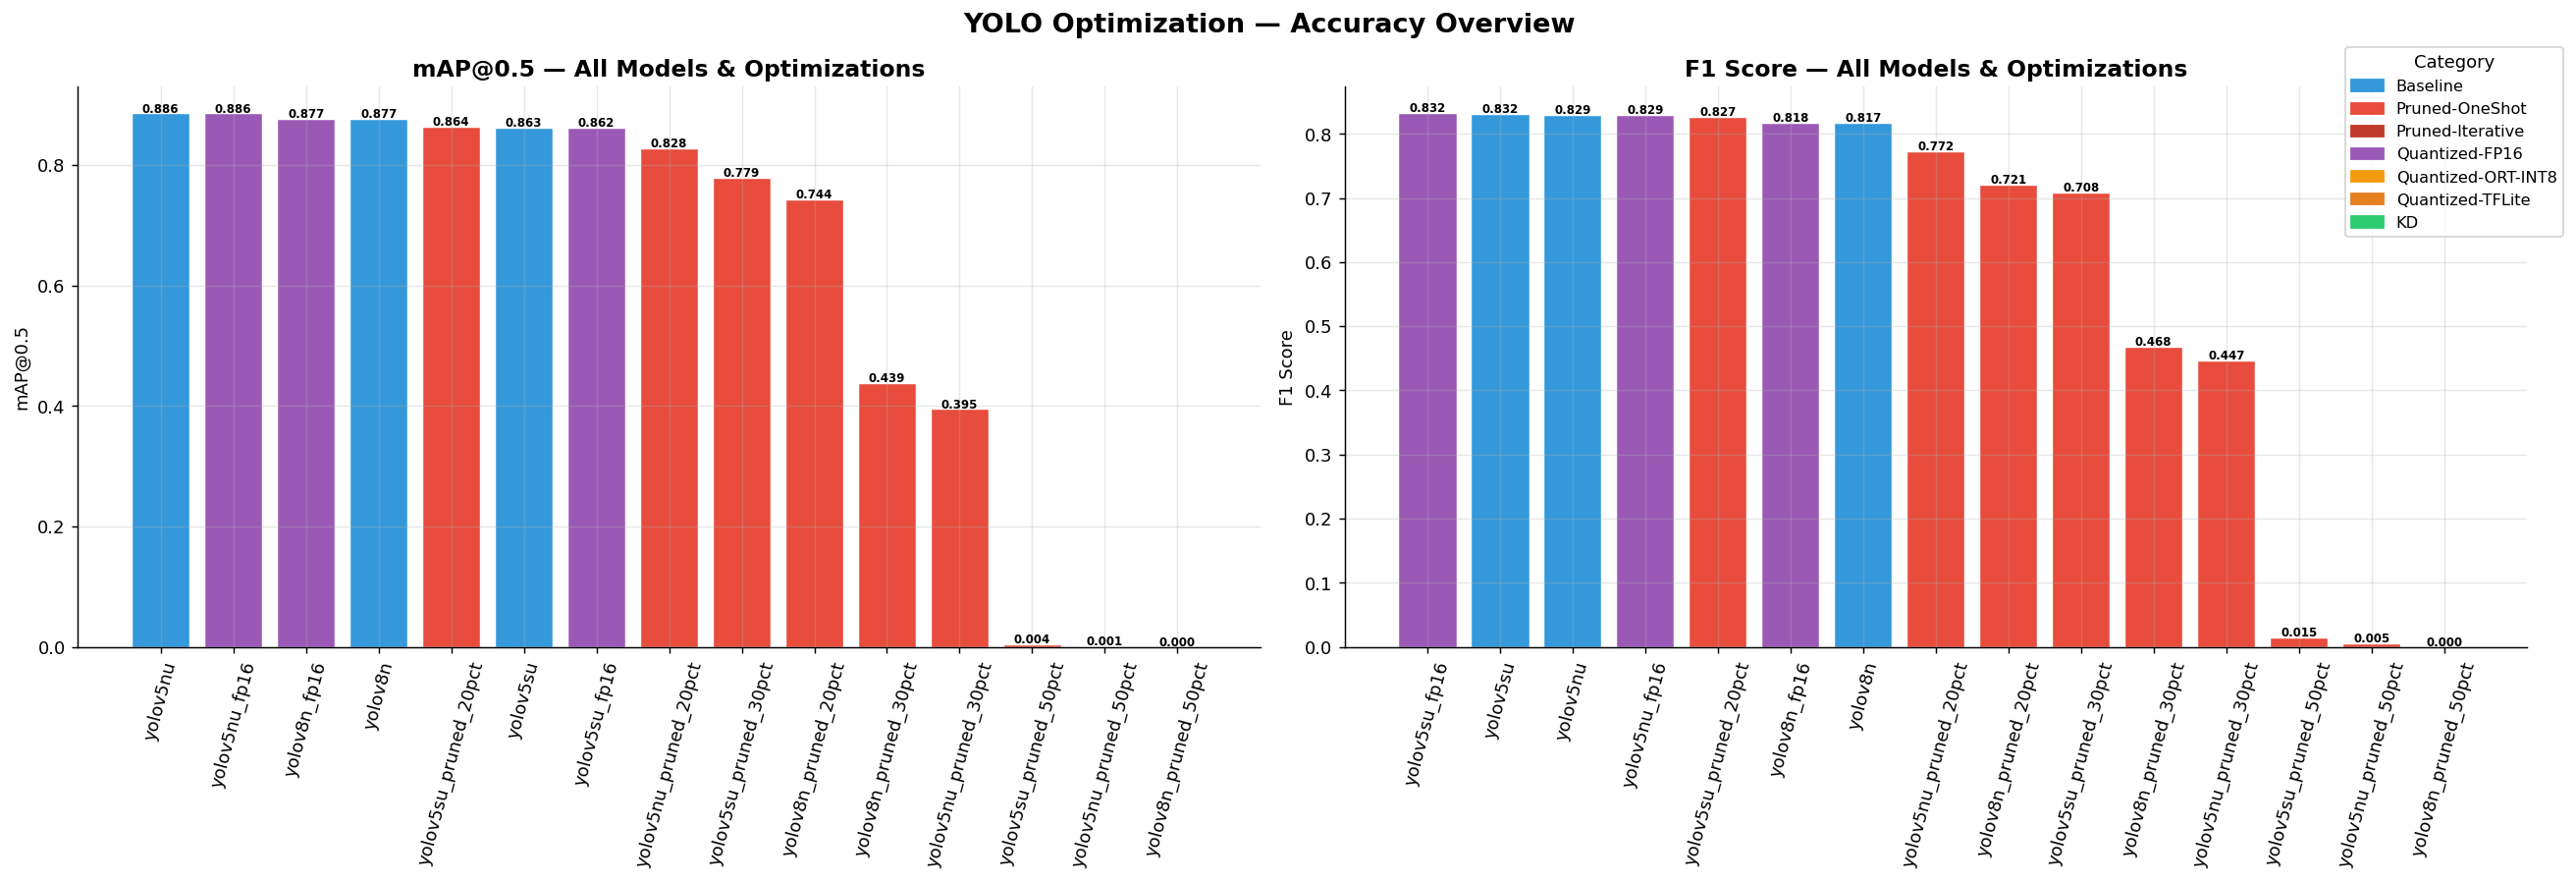

In [19]:
df_acc = df.dropna(subset=["mAP50"]).sort_values("mAP50", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

colors = [CAT_COLORS.get(c, "#95a5a6") for c in df_acc["Category"]]

bars = axes[0].bar(df_acc["Tag"], df_acc["mAP50"], color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("mAP@0.5 — All Models & Optimizations", fontsize=13, fontweight="bold")
axes[0].set_ylabel("mAP@0.5")
axes[0].tick_params(axis="x", rotation=75)
for b, v in zip(bars, df_acc["mAP50"]):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.3f}",
                 ha="center", fontsize=6.5, fontweight="bold")

df_f1 = df.dropna(subset=["F1"]).sort_values("F1", ascending=False).reset_index(drop=True)
colors2 = [CAT_COLORS.get(c, "#95a5a6") for c in df_f1["Category"]]
bars2 = axes[1].bar(df_f1["Tag"], df_f1["F1"], color=colors2, edgecolor="white", linewidth=0.8)
axes[1].set_title("F1 Score — All Models & Optimizations", fontsize=13, fontweight="bold")
axes[1].set_ylabel("F1 Score")
axes[1].tick_params(axis="x", rotation=75)
for b, v in zip(bars2, df_f1["F1"]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.3f}",
                 ha="center", fontsize=6.5, fontweight="bold")

patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
fig.legend(handles=patches, loc="upper right", fontsize=9, title="Category",
           bbox_to_anchor=(1.01, 0.95))

plt.suptitle("YOLO Optimization — Accuracy Overview", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("analysis_accuracy_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 📐 Cell A2 — Precision, Recall, mAP50-95 Grouped

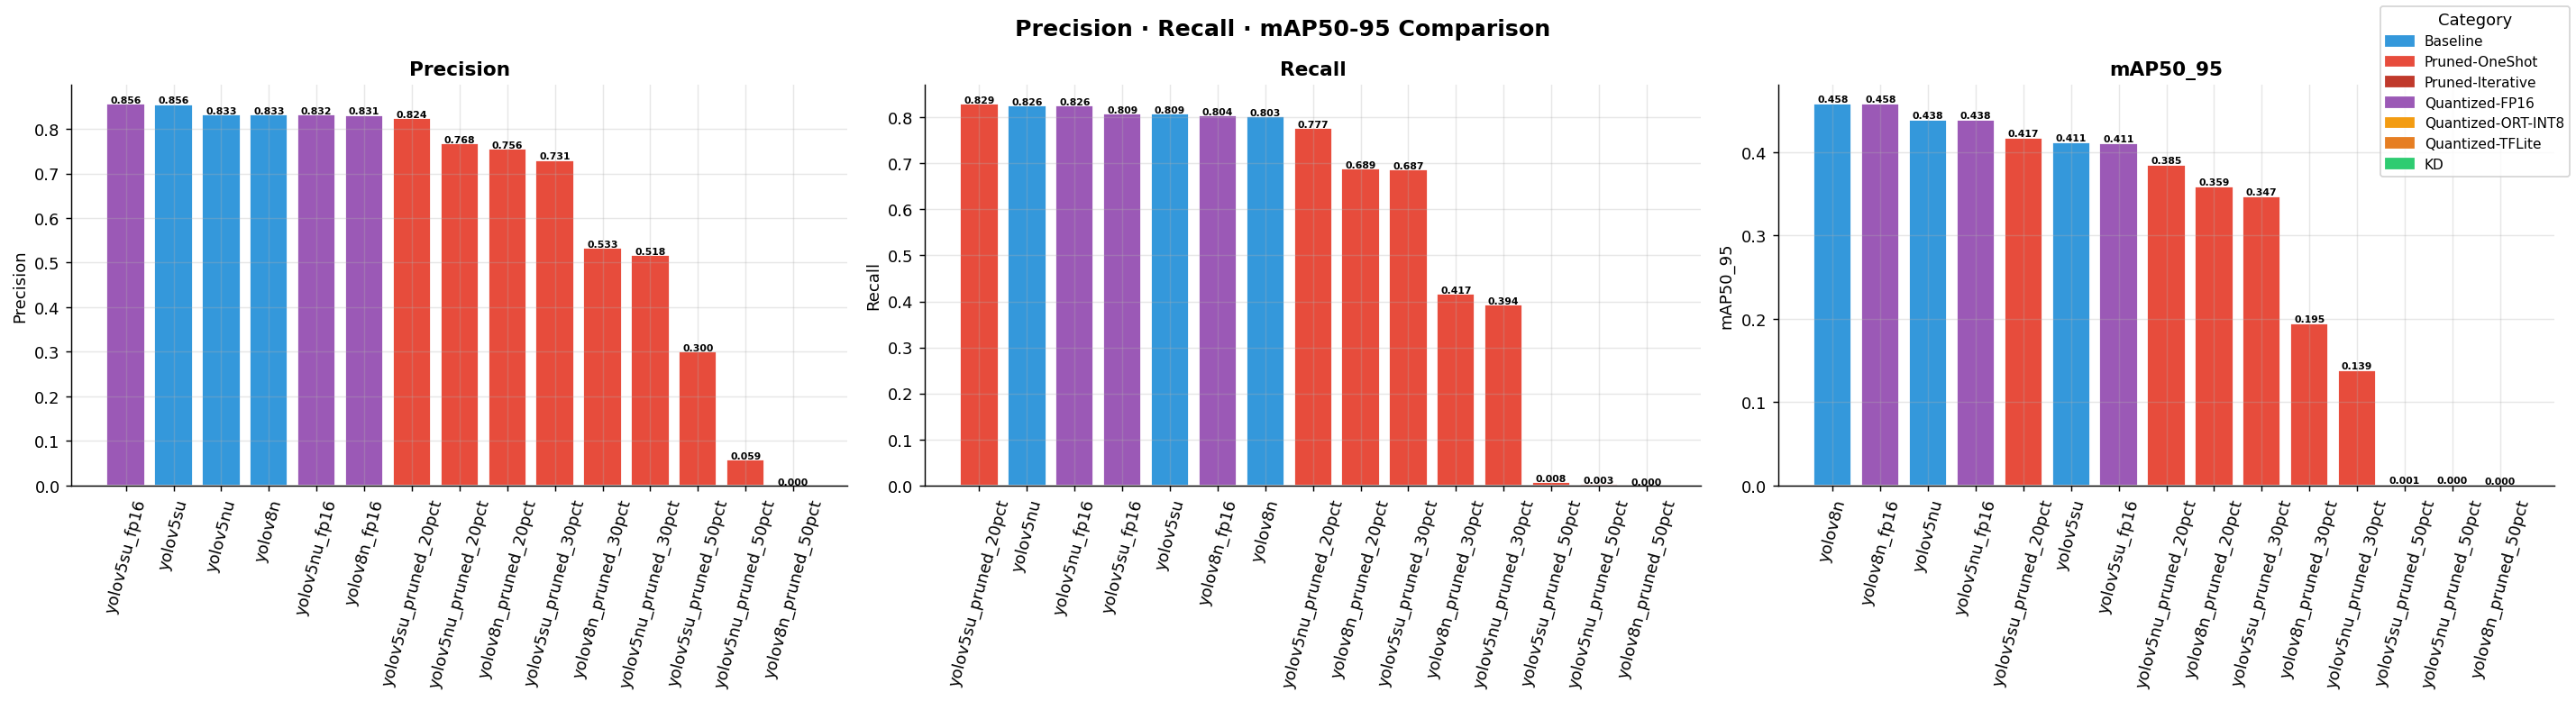

In [20]:
df_pr = df.dropna(subset=["Precision", "Recall", "mAP50_95"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
metrics = [("Precision", "#3498db"), ("Recall", "#e74c3c"), ("mAP50_95", "#2ecc71")]

for ax, (metric, color) in zip(axes, metrics):
    df_s = df_pr.sort_values(metric, ascending=False)
    cols = [CAT_COLORS.get(c, color) for c in df_s["Category"]]
    bars = ax.bar(df_s["Tag"], df_s[metric], color=cols, edgecolor="white")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=75)
    ax.set_ylabel(metric)
    for b, v in zip(bars, df_s[metric]):
        ax.text(b.get_x() + b.get_width()/2, v + 0.002,
                f"{v:.3f}", ha="center", fontsize=6, fontweight="bold")

patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
fig.legend(handles=patches, loc="upper right", fontsize=8.5, title="Category")
plt.suptitle("Precision · Recall · mAP50-95 Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("analysis_prec_recall_map95.png", dpi=150, bbox_inches="tight")
plt.show()

## 📦 Cell A3 — Model Size Comparison
Pruned models show both raw and gzipped (effective) file sizes. For unstructured pruning,
the gzipped figure is the realistic deployable size.

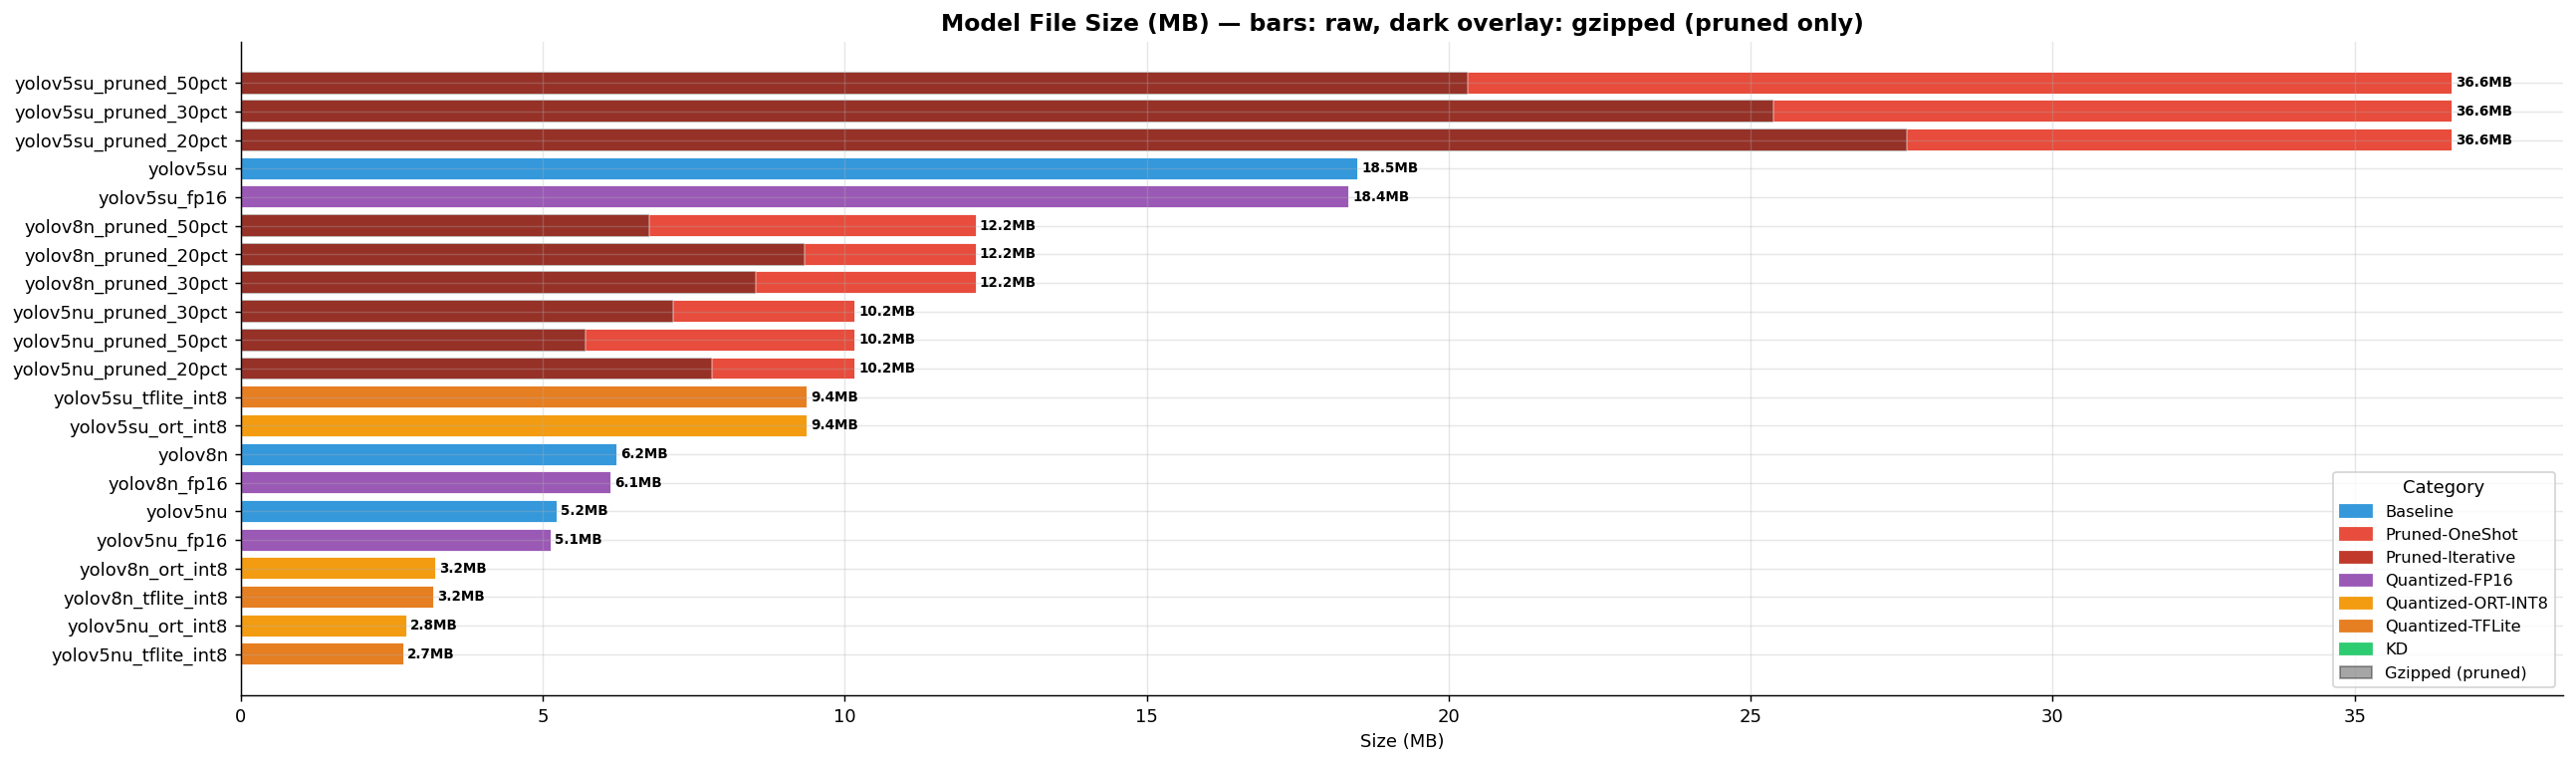

In [21]:
df_sz = df.dropna(subset=["FileSizeMB"]).sort_values("FileSizeMB").reset_index(drop=True)
cols  = [CAT_COLORS.get(c, "#95a5a6") for c in df_sz["Category"]]

fig, ax = plt.subplots(figsize=(20, 6))
bars = ax.barh(df_sz["Tag"], df_sz["FileSizeMB"], color=cols, edgecolor="white",
               label="Raw file size")
# Overlay gzipped size for pruned rows
for i, row in df_sz.iterrows():
    gz = row.get("FileSizeMB_gz")
    if pd.notna(gz) and row["Category"] in ("Pruned-OneShot", "Pruned-Iterative"):
        ax.barh(row["Tag"], gz, color="black", alpha=0.35, edgecolor="white")

for b, v in zip(bars, df_sz["FileSizeMB"]):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2, f"{v:.1f}MB",
            va="center", fontsize=7.5, fontweight="bold")

ax.set_title("Model File Size (MB) — bars: raw, dark overlay: gzipped (pruned only)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Size (MB)")
patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
patches.append(mpatches.Patch(color="black", alpha=0.35, label="Gzipped (pruned)"))
ax.legend(handles=patches, fontsize=9, title="Category")
plt.tight_layout()
plt.savefig("analysis_model_size.png", dpi=150, bbox_inches="tight")
plt.show()

## ⚡ Cell A4 — Inference Speed: GPU vs RPi-proxy CPU
RPi numbers are now real ORT CPU benchmarks (threads pinned), not formula estimates.

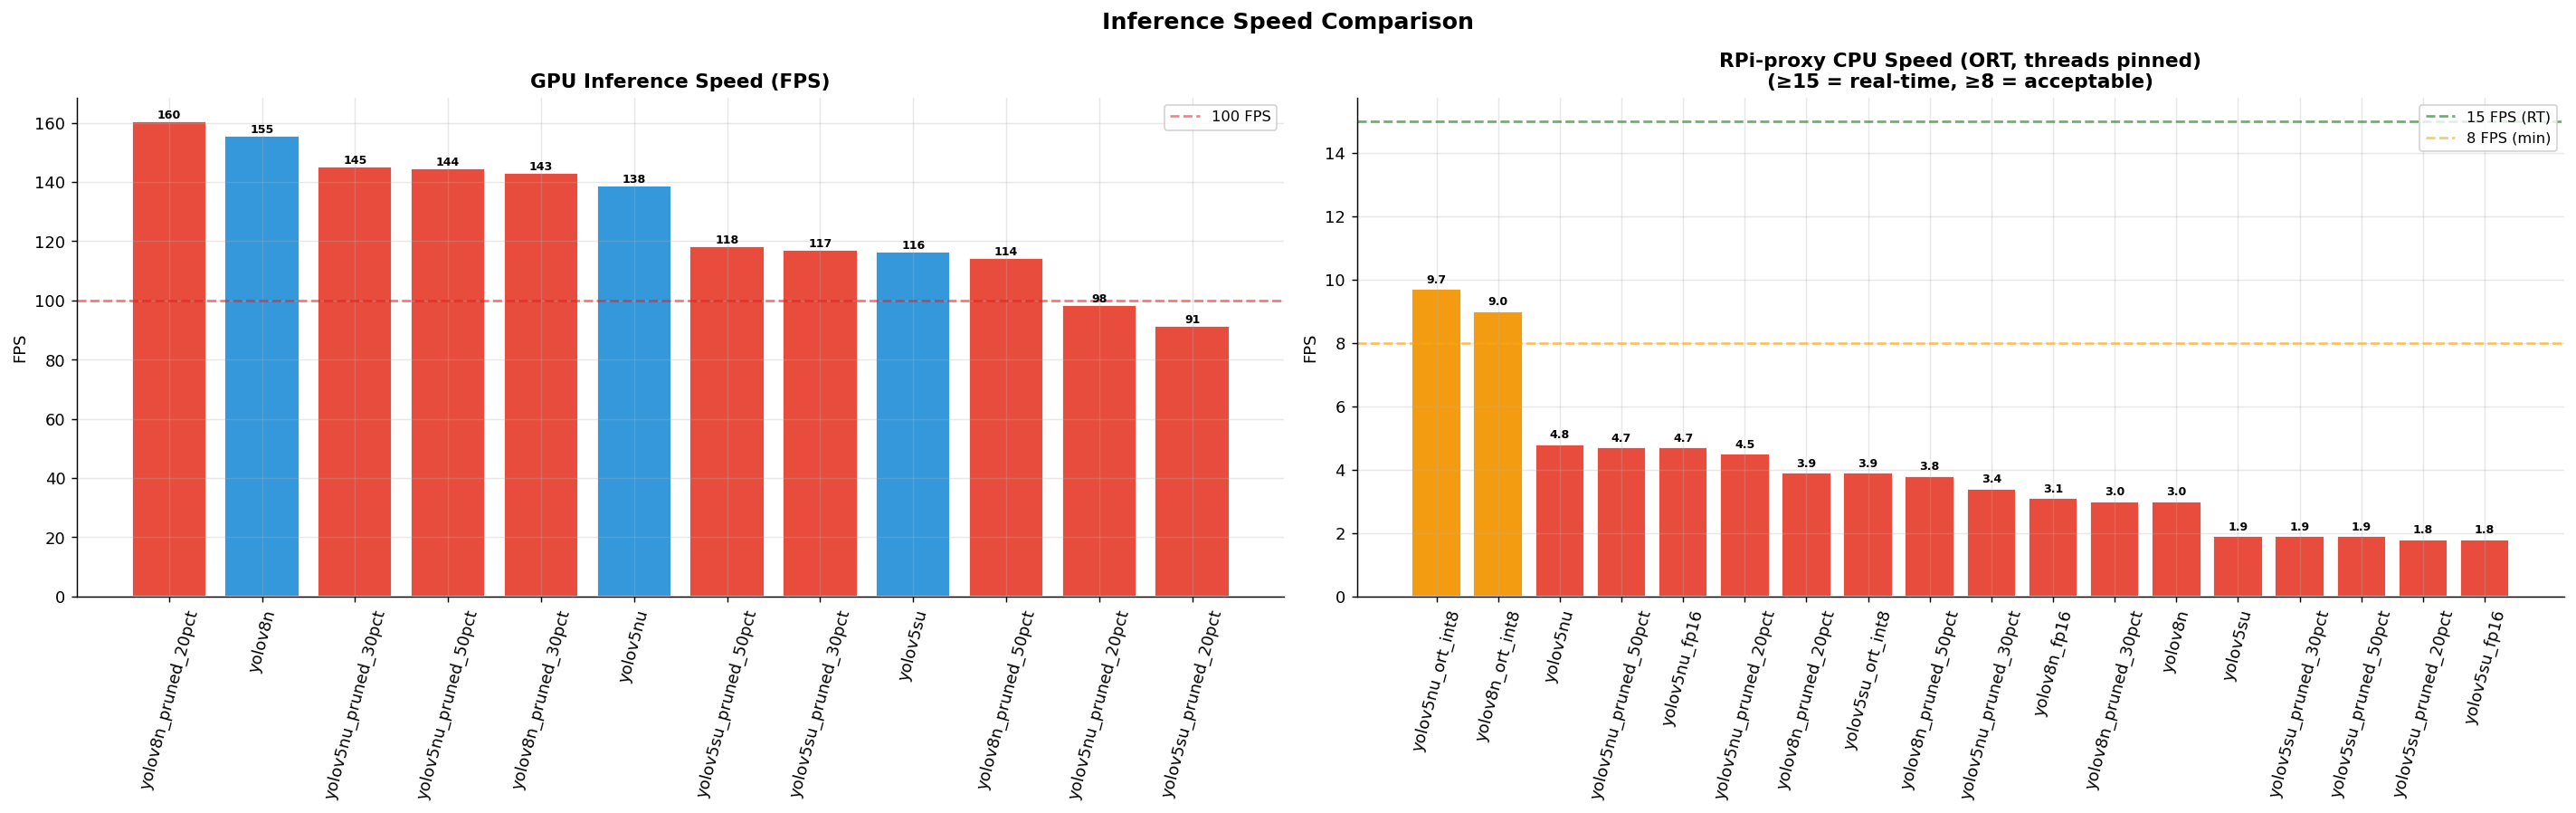

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

df_gpu = df.dropna(subset=["GPU_FPS"]).sort_values("GPU_FPS", ascending=False)
if not df_gpu.empty:
    cols_g = [CAT_COLORS.get(c, "#95a5a6") for c in df_gpu["Category"]]
    bars_g = axes[0].bar(df_gpu["Tag"], df_gpu["GPU_FPS"], color=cols_g, edgecolor="white")
    axes[0].set_title("GPU Inference Speed (FPS)", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("FPS")
    axes[0].tick_params(axis="x", rotation=75)
    axes[0].axhline(100, color="red", linestyle="--", alpha=0.5, label="100 FPS")
    axes[0].legend(fontsize=9)
    for b, v in zip(bars_g, df_gpu["GPU_FPS"]):
        axes[0].text(b.get_x() + b.get_width()/2, v + 1, str(int(v)),
                     ha="center", fontsize=7, fontweight="bold")

df_rpi = df.dropna(subset=["RPi_FPS"]).sort_values("RPi_FPS", ascending=False)
if not df_rpi.empty:
    rpi_palette = ["#2ecc71" if v >= 15 else "#f39c12" if v >= 8 else "#e74c3c"
                   for v in df_rpi["RPi_FPS"]]
    bars_r = axes[1].bar(df_rpi["Tag"], df_rpi["RPi_FPS"], color=rpi_palette, edgecolor="white")
    axes[1].set_title("RPi-proxy CPU Speed (ORT, threads pinned)\n"
                      "(≥15 = real-time, ≥8 = acceptable)",
                      fontsize=12, fontweight="bold")
    axes[1].set_ylabel("FPS")
    axes[1].tick_params(axis="x", rotation=75)
    axes[1].axhline(15, color="green",  linestyle="--", alpha=0.6, label="15 FPS (RT)")
    axes[1].axhline(8,  color="orange", linestyle="--", alpha=0.6, label="8 FPS (min)")
    axes[1].legend(fontsize=9)
    for b, v in zip(bars_r, df_rpi["RPi_FPS"]):
        axes[1].text(b.get_x() + b.get_width()/2, v + 0.2, f"{v:.1f}",
                     ha="center", fontsize=7, fontweight="bold")

plt.suptitle("Inference Speed Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("analysis_speed.png", dpi=150, bbox_inches="tight")
plt.show()

## 🎯 Cell A5 — Pareto Frontier: Accuracy vs Effective Size

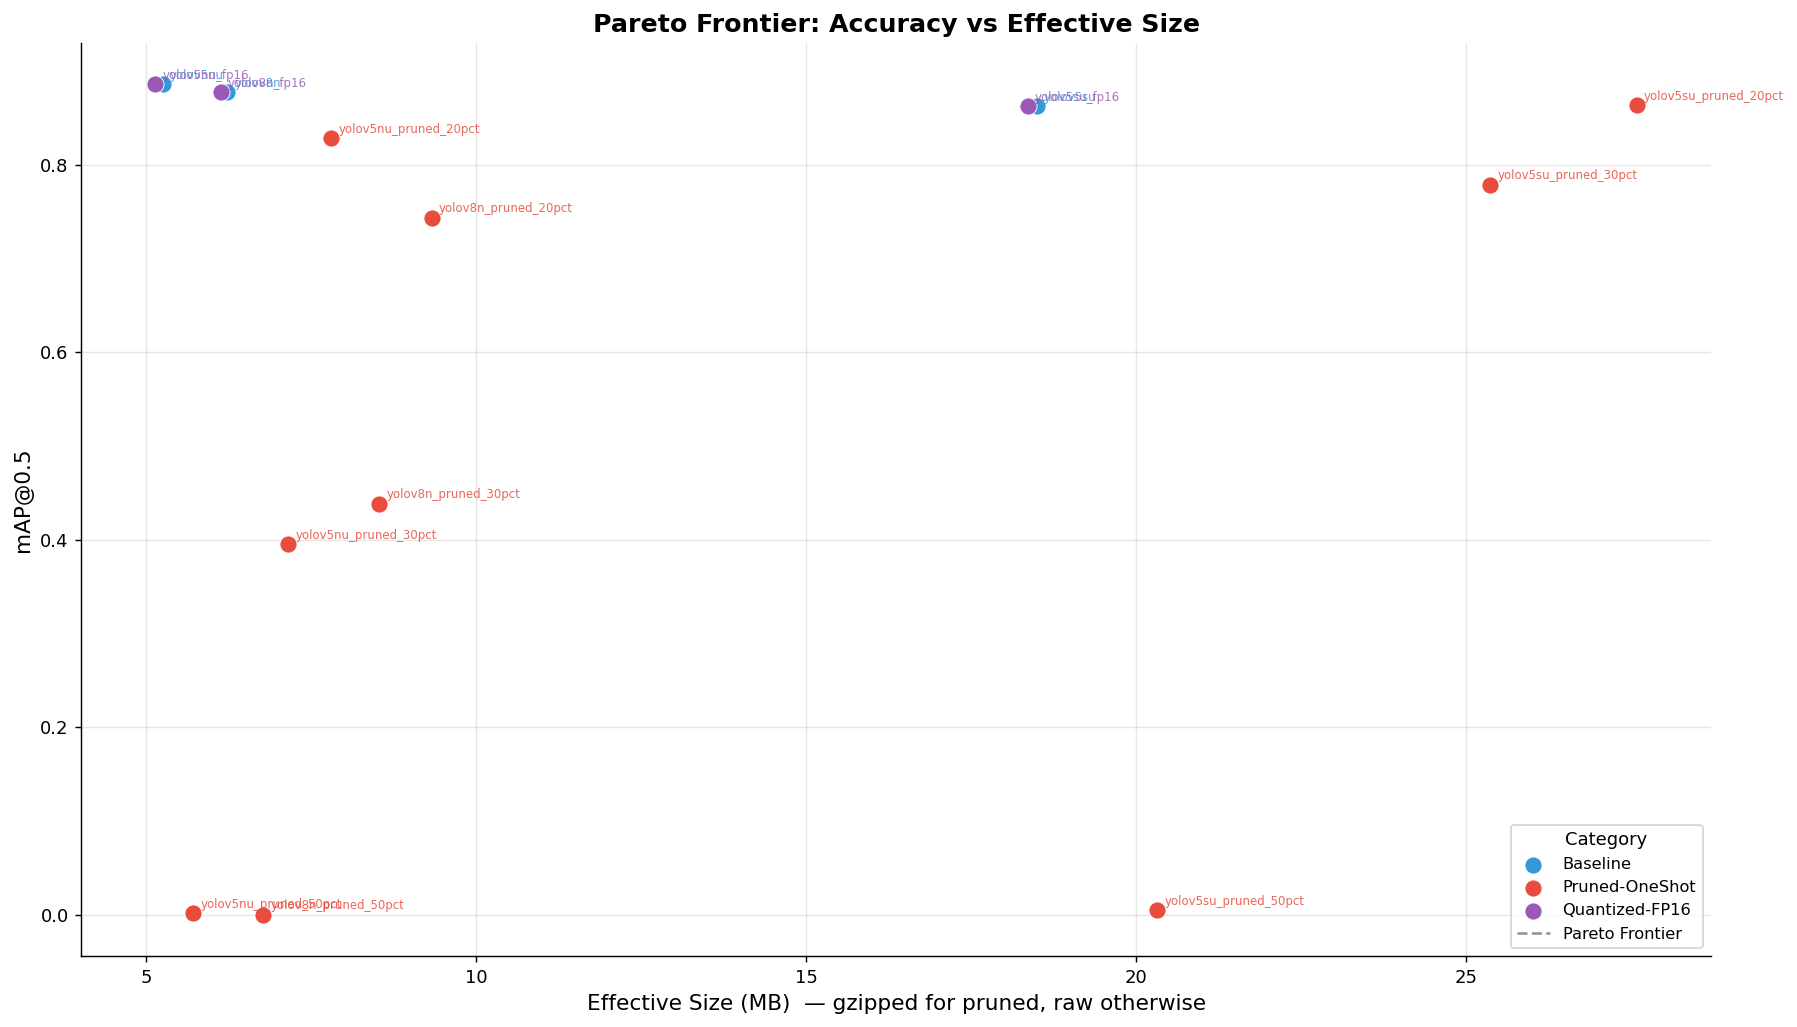

In [23]:
df_pareto = df.dropna(subset=["mAP50", "EffectiveSizeMB"]).copy()

fig, ax = plt.subplots(figsize=(14, 8))

for cat, grp in df_pareto.groupby("Category"):
    color = CAT_COLORS.get(cat, "#95a5a6")
    ax.scatter(grp["EffectiveSizeMB"], grp["mAP50"], c=color, s=90,
               label=cat, zorder=3, edgecolors="white", linewidth=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row["Tag"], (row["EffectiveSizeMB"], row["mAP50"]),
                    xytext=(4, 3), textcoords="offset points", fontsize=6.5,
                    color=color, alpha=0.85)

df_sorted = df_pareto.sort_values("EffectiveSizeMB")
pareto_pts = []
best_map = -1
for _, r in df_sorted.iterrows():
    if r["mAP50"] > best_map:
        best_map = r["mAP50"]
        pareto_pts.append(r)
if pareto_pts:
    pf = pd.DataFrame(pareto_pts)
    ax.plot(pf["EffectiveSizeMB"], pf["mAP50"], "k--", linewidth=1.5,
            alpha=0.4, label="Pareto Frontier")

ax.set_xlabel("Effective Size (MB)  — gzipped for pruned, raw otherwise", fontsize=12)
ax.set_ylabel("mAP@0.5", fontsize=12)
ax.set_title("Pareto Frontier: Accuracy vs Effective Size", fontsize=14, fontweight="bold")
ax.legend(fontsize=9, title="Category")
plt.tight_layout()
plt.savefig("analysis_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## 📋 Cell A6 — Full Comparison Table

In [24]:
show_cols = ["Tag", "Category", "mAP50", "mAP50_95", "F1",
             "Precision", "Recall", "FileSizeMB", "FileSizeMB_gz", "Sparsity",
             "GPU_FPS", "RPi_FPS"]
disp_cols = [c for c in show_cols if c in df.columns]

disp_df = df[disp_cols].sort_values("mAP50", ascending=False, na_position="last").copy()

for col in ["mAP50", "mAP50_95", "F1", "Precision", "Recall"]:
    if col in disp_df:
        disp_df[col] = disp_df[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")

print("="*130)
print("  FULL MODEL COMPARISON TABLE (sorted by mAP50 desc)")
print("="*130)
print(disp_df.to_string(index=False))

disp_df.to_csv("yolo_optimization_comparison.csv", index=False)
print("\nSaved → yolo_optimization_comparison.csv")

  FULL MODEL COMPARISON TABLE (sorted by mAP50 desc)
                  Tag           Category  mAP50 mAP50_95     F1 Precision Recall  FileSizeMB  FileSizeMB_gz  Sparsity  GPU_FPS  RPi_FPS
             yolov5nu           Baseline 0.8859   0.4383 0.8294    0.8327 0.8260        5.25           4.74       0.0    138.8      4.8
        yolov5nu_fp16     Quantized-FP16 0.8859   0.4383 0.8290    0.8320 0.8260        5.14           4.69       NaN      NaN      4.7
         yolov8n_fp16     Quantized-FP16 0.8775   0.4576 0.8175    0.8314 0.8041        6.13           5.62       NaN      NaN      3.1
              yolov8n           Baseline 0.8774   0.4576 0.8174    0.8327 0.8027        6.23           5.66       0.0    155.7      3.0
yolov5su_pruned_20pct     Pruned-OneShot 0.8636   0.4173 0.8266    0.8244 0.8289       36.62          27.59      18.1     91.5      1.8
             yolov5su           Baseline 0.8625   0.4112 0.8316    0.8556 0.8089       18.50          17.02       0.0    116.5     

## 💾 Cell A7 — List All Saved Files

In [ ]:
import glob

print("BASELINE WEIGHTS:")
for f in sorted(glob.glob(f"{CFG['save_dir']}/*.pt")):
    print(f"  {os.path.getsize(f)/1e6:7.1f} MB  {f}")

print("\nOPTIMIZED MODELS:")
for f in sorted(glob.glob(f"{CFG['opt_dir']}/*")):
    print(f"  {os.path.getsize(f)/1e6:7.1f} MB  {f}")

print("\nONNX EXPORTS:")
for f in sorted(glob.glob(f"{CFG['onnx_dir']}/*.onnx")):
    print(f"  {os.path.getsize(f)/1e6:7.1f} MB  {f}")

print("\nTFLITE EXPORTS:")
for f in sorted(glob.glob("**/*.tflite", recursive=True)):
    print(f"  {os.path.getsize(f)/1e6:7.1f} MB  {f}")

print("\nANALYSIS PLOTS:")
for f in sorted(glob.glob("analysis_*.png")):
    print(f"  {f}")

print("\n🎉 All done!")


## ⬇️ Cell A8 — Download Everything to your PC (Colab-safe)

Colab runtime is ephemeral — when it disconnects, every file in `/content` is gone. The cells below:

1. **Bundle every important output** (optimized weights, ONNX exports, TFLite, plots, CSV) into a single zip.
2. **Trigger a browser download** so the zip lands in your local Downloads folder automatically.
3. **Also copy to Google Drive** as redundant backup (since you already mounted it).

Run this cell *whenever* you want to checkpoint. Run it again at the very end too.


In [ ]:
import zipfile, glob, datetime

ZIP_NAME = f"yolo_optimization_results_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"

# Collect everything worth saving
paths_to_bundle = []
paths_to_bundle += sorted(glob.glob(f"{CFG['save_dir']}/*.pt"))           # baseline weights
paths_to_bundle += sorted(glob.glob(f"{CFG['opt_dir']}/*"))               # optimized models
paths_to_bundle += sorted(glob.glob(f"{CFG['onnx_dir']}/*.onnx"))         # ONNX exports
paths_to_bundle += sorted(glob.glob("**/*.tflite", recursive=True))       # TFLite exports
paths_to_bundle += sorted(glob.glob("analysis_*.png"))                    # plots
if os.path.exists("yolo_optimization_comparison.csv"):                    # comparison CSV
    paths_to_bundle.append("yolo_optimization_comparison.csv")
# also sweep KD run artifacts (best.pt and training logs)
paths_to_bundle += sorted(glob.glob("runs/kd/**/*.pt", recursive=True))
paths_to_bundle += sorted(glob.glob("runs/kd/**/results.csv", recursive=True))

# Deduplicate while preserving order
seen, unique_paths = set(), []
for p in paths_to_bundle:
    if p not in seen and os.path.exists(p):
        unique_paths.append(p); seen.add(p)

print(f"Packaging {len(unique_paths)} files into {ZIP_NAME} …")
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    for p in unique_paths:
        zf.write(p)
        print(f"  + {os.path.getsize(p)/1e6:7.1f} MB  {p}")

zip_mb = os.path.getsize(ZIP_NAME) / 1e6
print(f"\n📦 Wrote {ZIP_NAME}  ({zip_mb:.1f} MB)")

# 1) Backup to Google Drive (already mounted; survives runtime reset)
DRIVE_BACKUP_DIR = "/content/drive/MyDrive/yolo_optimization_backups"
try:
    if os.path.isdir("/content/drive/MyDrive"):
        os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
        drive_dest = os.path.join(DRIVE_BACKUP_DIR, ZIP_NAME)
        shutil.copy(ZIP_NAME, drive_dest)
        print(f"💾 Drive backup: {drive_dest}")
    else:
        print("[INFO] Drive not mounted — skipping Drive backup.")
except Exception as e:
    print(f"[WARN] Drive backup failed: {e}")

# 2) Trigger browser download to your local PC (Colab-only)
try:
    from google.colab import files
    print("\n⬇️  Triggering browser download — check your Downloads folder.")
    print("    (If the download doesn't start, look in the Files panel on the left,")
    print("     right-click the zip, and choose 'Download'.)")
    files.download(ZIP_NAME)
except ImportError:
    print("\n[INFO] Not running on Colab — copy the zip from your filesystem manually.")
except Exception as e:
    print(f"\n[WARN] Auto-download failed ({e}).")
    print("       Open the Files panel on the left, right-click the zip, and Download.")
